# Project 1 — Heart Segmentation Evaluation
This notebook evaluates the trained U-Net against TotalSegmentator ground truth:
- Dice score per scan on the test set
- Inference time comparison (U-Net vs TotalSegmentator)
- Visual overlay: prediction vs ground truth

In [1]:
import time
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pathlib import Path
from monai.networks.nets import UNet
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete

ROOT      = Path(r'C:\Users\level\OneDrive\Escritorio\COCA')
RESAMPLED = ROOT / 'data_resampled'
GT_DIR    = ROOT / 'heart_gt'
MODEL_PATH = ROOT / 'models' / 'best_unet.pth'
LABEL_CSV  = ROOT / 'data_canonical' / 'tables' / 'label_results.csv'

SLICE_SIZE = 256
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


In [5]:
# Load model
model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=2,
    channels=(32, 64, 128, 256),
    strides=(2, 2, 2),
    num_res_units=1,
).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print('Model loaded.')

Model loaded.


In [6]:
def apply_hu_window(vol, center=40, width=400):
    lo, hi = center - width // 2, center + width // 2
    vol = np.clip(vol, lo, hi)
    return ((vol - lo) / (hi - lo)).astype(np.float32)

def predict_volume(scan_id):
    """Runs U-Net inference on a full volume. Returns (pred_mask_3d, elapsed_seconds)."""
    img_path = RESAMPLED / scan_id / f'{scan_id}_img.nii.gz'
    img_sitk = sitk.ReadImage(str(img_path))
    img_arr  = apply_hu_window(sitk.GetArrayFromImage(img_sitk))   # (Z,H,W)

    pred_vol = np.zeros(img_arr.shape, dtype=np.uint8)

    t0 = time.time()
    with torch.no_grad():
        for z in range(img_arr.shape[0]):
            slc = torch.from_numpy(img_arr[z]).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
            slc = F.interpolate(slc, size=(SLICE_SIZE, SLICE_SIZE), mode='bilinear', align_corners=False)
            slc = slc.to(DEVICE)
            out = model(slc)                                  # (1,2,H,W)
            pred = out.argmax(dim=1).squeeze().cpu().numpy()  # (H,W)  0 or 1
            # Resize back to original spatial dims
            orig_h, orig_w = img_arr.shape[1], img_arr.shape[2]
            pred_t = torch.from_numpy(pred.astype(np.float32)).unsqueeze(0).unsqueeze(0)
            pred_t = F.interpolate(pred_t, size=(orig_h, orig_w), mode='nearest')
            pred_vol[z] = pred_t.squeeze().numpy().astype(np.uint8)
    elapsed = time.time() - t0

    return pred_vol, elapsed

In [7]:
# Evaluate on all labelled scans (use last 20% as test set, matching train.py split)
label_df  = pd.read_csv(LABEL_CSV)
scan_ids  = label_df['scan_id'].tolist()

np.random.seed(42)
np.random.shuffle(scan_ids)
n_val    = int(len(scan_ids) * 0.2)
test_ids = scan_ids[:n_val]    # same split as train.py

print(f'Evaluating on {len(test_ids)} test scans...')

results = []
for scan_id in test_ids:
    gt_path = GT_DIR / f'{scan_id}_heart.nii.gz'
    if not gt_path.exists():
        continue

    gt_arr   = (sitk.GetArrayFromImage(sitk.ReadImage(str(gt_path))) > 0).astype(np.uint8)
    pred_arr, elapsed = predict_volume(scan_id)

    # Dice score
    intersection = (pred_arr * gt_arr).sum()
    dice = (2 * intersection) / (pred_arr.sum() + gt_arr.sum() + 1e-6)

    results.append({'scan_id': scan_id, 'dice': round(float(dice), 4),
                    'unet_time_s': round(elapsed, 2),
                    'ts_time_s': label_df.set_index('scan_id').loc[scan_id, 'ts_time_s']})
    print(f'  {scan_id}: Dice={dice:.4f}  U-Net={elapsed:.1f}s')

results_df = pd.DataFrame(results)
results_df.to_csv(ROOT / 'models' / 'eval_results.csv', index=False)
results_df

Evaluating on 8 test scans...
  a3a1e8324902: Dice=0.8917  U-Net=1.0s
  191517c5fbf7: Dice=0.7934  U-Net=0.9s
  3463607d9add: Dice=0.8225  U-Net=1.2s
  a6d44593ed69: Dice=0.8463  U-Net=1.0s
  85d832423677: Dice=0.7657  U-Net=1.0s
  2b69dbfff60e: Dice=0.7575  U-Net=1.2s
  34ca4593c4b0: Dice=0.8441  U-Net=1.1s
  bde839b0e74c: Dice=0.8746  U-Net=1.1s


,scan_id,dice,unet_time_s,ts_time_s
0,a3a1e8324902,0.8917,1.00,31.01
1,191517c5fbf7,0.7934,0.93,29.93
2,3463607d9add,0.8225,1.15,29.87
3,a6d44593ed69,0.8463,1.01,29.78
4,85d832423677,0.7657,0.96,31.95
5,2b69dbfff60e,0.7575,1.16,30.13
6,34ca4593c4b0,0.8441,1.07,32.42
7,bde839b0e74c,0.8746,1.15,30.90


In [8]:
# Summary stats
print('===== Evaluation Summary =====')
print(f"Mean Dice:          {results_df['dice'].mean():.4f}")
print(f"Median Dice:        {results_df['dice'].median():.4f}")
print(f"Scans with Dice>0.85: {(results_df['dice'] > 0.85).sum()} / {len(results_df)}")
print(f"Mean U-Net time:    {results_df['unet_time_s'].mean():.1f}s")
print(f"Mean TS time:       {results_df['ts_time_s'].mean():.1f}s")
print(f"Speedup:            {results_df['ts_time_s'].mean() / results_df['unet_time_s'].mean():.1f}x faster")

===== Evaluation Summary =====
Mean Dice:          0.8245
Median Dice:        0.8333
Scans with Dice>0.85: 2 / 8
Mean U-Net time:    1.1s
Mean TS time:       30.7s
Speedup:            29.2x faster


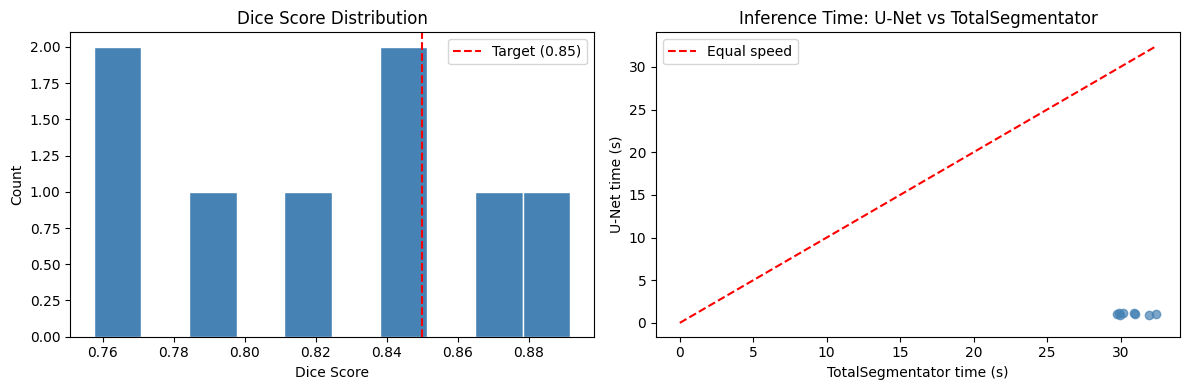

In [9]:
# Dice distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(results_df['dice'], bins=10, color='steelblue', edgecolor='white')
axes[0].axvline(0.85, color='red', linestyle='--', label='Target (0.85)')
axes[0].set_xlabel('Dice Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Dice Score Distribution')
axes[0].legend()

axes[1].scatter(results_df['ts_time_s'], results_df['unet_time_s'], alpha=0.7, color='steelblue')
axes[1].plot([0, results_df['ts_time_s'].max()], [0, results_df['ts_time_s'].max()],
             'r--', label='Equal speed')
axes[1].set_xlabel('TotalSegmentator time (s)')
axes[1].set_ylabel('U-Net time (s)')
axes[1].set_title('Inference Time: U-Net vs TotalSegmentator')
axes[1].legend()

plt.tight_layout()
plt.savefig(ROOT / 'models' / 'eval_plots.png', dpi=150)
plt.show()

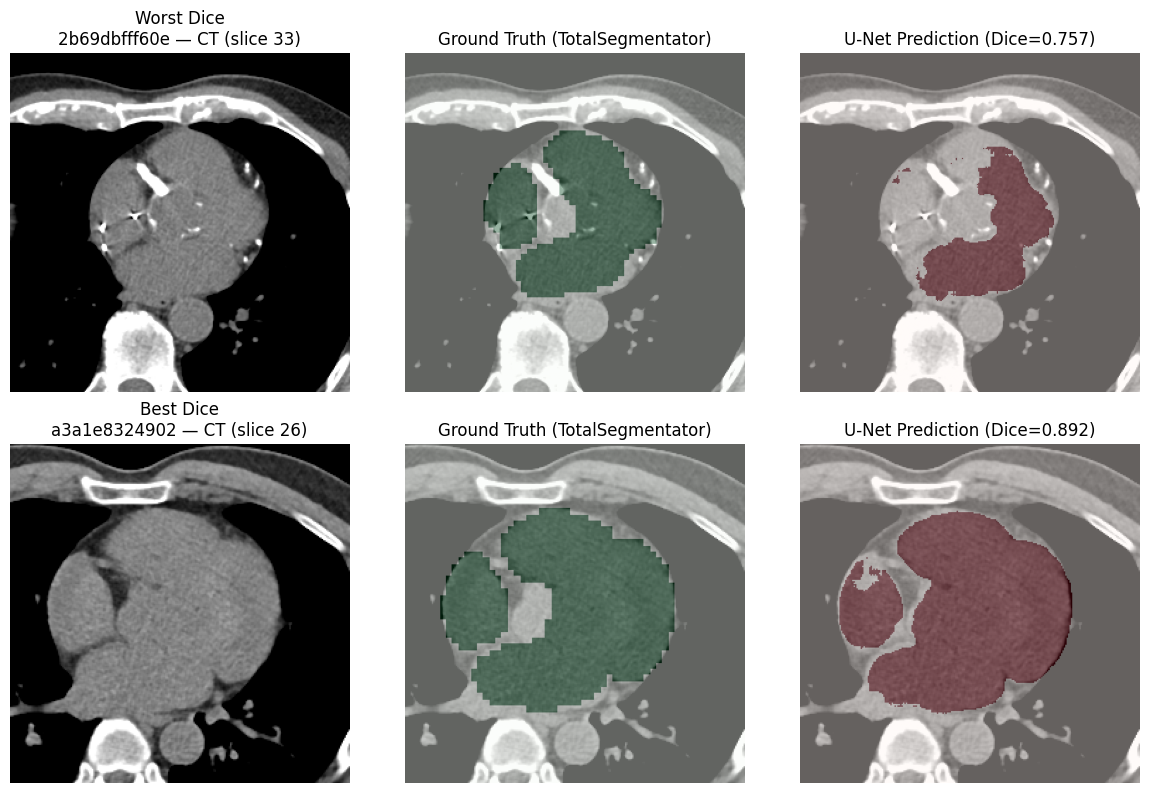

Saved eval_plots.png and visual_overlay.png


In [10]:
# Visual overlay for the best and worst scan
results_df_sorted = results_df.sort_values('dice')
to_show = [
    ('Worst Dice', results_df_sorted.iloc[0]['scan_id']),
    ('Best Dice',  results_df_sorted.iloc[-1]['scan_id']),
]

fig, axes = plt.subplots(len(to_show), 3, figsize=(12, 4 * len(to_show)))

for row_i, (label, scan_id) in enumerate(to_show):
    img_arr  = apply_hu_window(sitk.GetArrayFromImage(
        sitk.ReadImage(str(RESAMPLED / scan_id / f'{scan_id}_img.nii.gz'))))
    gt_arr   = (sitk.GetArrayFromImage(sitk.ReadImage(
        str(GT_DIR / f'{scan_id}_heart.nii.gz'))) > 0).astype(np.uint8)
    pred_arr, _ = predict_volume(scan_id)

    # Find middle slice with most heart tissue
    heart_slices = np.where(gt_arr.sum(axis=(1,2)) > 0)[0]
    z = int(heart_slices[len(heart_slices)//2]) if len(heart_slices) else img_arr.shape[0]//2

    dice_val = results_df.set_index('scan_id').loc[scan_id, 'dice']

    axes[row_i, 0].imshow(img_arr[z], cmap='gray')
    axes[row_i, 0].set_title(f'{label}\n{scan_id} — CT (slice {z})')
    axes[row_i, 0].axis('off')

    axes[row_i, 1].imshow(img_arr[z], cmap='gray')
    axes[row_i, 1].imshow(gt_arr[z], alpha=0.4, cmap='Greens')
    axes[row_i, 1].set_title('Ground Truth (TotalSegmentator)')
    axes[row_i, 1].axis('off')

    axes[row_i, 2].imshow(img_arr[z], cmap='gray')
    axes[row_i, 2].imshow(pred_arr[z], alpha=0.4, cmap='Reds')
    axes[row_i, 2].set_title(f'U-Net Prediction (Dice={dice_val:.3f})')
    axes[row_i, 2].axis('off')

plt.tight_layout()
plt.savefig(ROOT / 'models' / 'visual_overlay.png', dpi=150)
plt.show()
print('Saved eval_plots.png and visual_overlay.png')